In [32]:
from qiskit import __version__
print(__version__)

2.1.1


# Importing Packages

In [58]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec

# Defining Global Variable

In [ ]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))

# Creating Custom Gates

In [35]:
# Create custom gates
H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

ID_matrix = IGate().to_matrix()
encoding_err = UnitaryGate(ID_matrix, label='encoding_err')

idle_matrix = IGate().to_matrix()
idle = UnitaryGate(idle_matrix, label='idle')

ry_sub = QuantumCircuit(1, name='RY_custom')
ry_sub.ry(theta, 0)
RY_custom = ry_sub.to_gate()

# 3-Qubit MSD Circuit

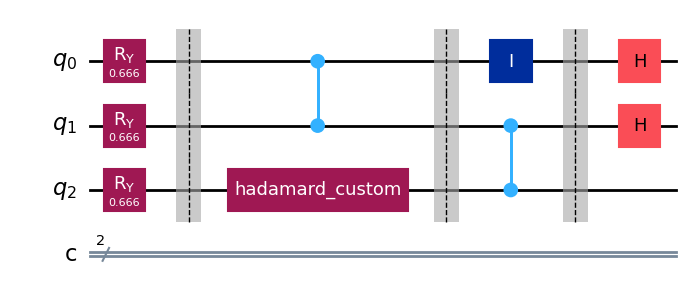

In [36]:
circuit = QuantumCircuit(3, 2)

# State prep
for i in range(3):
    circuit.ry(theta, i)
circuit.barrier()

circuit.cz(0,1)
circuit.append(hadamard_custom, [2])
circuit.barrier()

circuit.id(0)
circuit.cz(1,2)
circuit.barrier()

circuit.h(0)
circuit.h(1)

display(circuit.draw(output='mpl'))

# Infidelity to Error Rates

In [37]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [38]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [39]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

When all physical error sources are included, we compute the infidelity of the post-selected output state vectors.

In [ ]:
# Ideal dm

# Construct |000><000|.
one_q_zero_dm = np.matmul([[1], [0]], [[1, 0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

# Apply R_y(theta) to the first qubit.
ry_theta = np.array([
    [np.cos(theta / 2), -np.sin(theta / 2)],
    [np.sin(theta / 2),  np.cos(theta / 2)]
])
ry_i_i = np.kron(ry_theta, np.kron(np.eye(2), np.eye(2)))

ideal = ry_i_i @ ideal @ ry_i_i.conj().T

# Normalize and convert to Qiskit's DensityMatrix type.
ideal /= np.trace(ideal)
ideal = DensityMatrix(ideal)

In [ ]:
# Store average fidelities and uncertainties.
all_fidelity = []
all_fidelity_unc = []

shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()

    # Add depolarizing noise to each operation type.
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['hadamard_custom']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(idle_gate_error_prob[i], 1),
        ['id']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_gate_error_prob[i], 2),
        ['cz']
    )

    # Add readout errors on the measured qubits.
    readout_err = ReadoutError([
        [1 - spam0[i], spam0[i]],
        [spam1[i], 1 - spam1[i]]
    ])
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])

    # Measure for post-selection and save the conditional statevectors.
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1])
    meas_circuit_noise.append(
        SaveStatevector(
            num_qubits=3,
            label='state_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit_noise.qubits
    )

    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()

    # Keep only post-selected shots with measurement outcome 00.
    res_statevectors = result.data()['state_post']
    accepted_statevectors = res_statevectors['0x0']
    num_meas = len(accepted_statevectors)

    # Average fidelity over accepted shots.
    sumfid = 0
    for shot in accepted_statevectors:
        sumfid += state_fidelity(shot, ideal)

    sumfid /= num_meas

    all_fidelity.append(sumfid)

    # 95% normal-approximation uncertainty.
    all_fidelity_unc.append(
        1.96 * np.sqrt(sumfid * (1 - sumfid) / num_meas)
    )

# Convert fidelities to infidelities.
all_infidelity = [1 - f for f in all_fidelity]

Input simulations

In [ ]:
# Construct |0><0|.
one_q_zero_dm = np.matmul([[1], [0]], [[1, 0]])

# Apply R_y(theta) to prepare the ideal input state.
ideal_input = ry_theta @ one_q_zero_dm @ ry_theta.conj().T

# Normalize and convert to Qiskit's DensityMatrix type.
ideal_input /= np.trace(ideal_input)
ideal_input = DensityMatrix(ideal_input)

In [27]:
input_circuit = QuantumCircuit(1)
input_circuit.ry(theta,0)

In [ ]:
# Store input-state fidelities.
all_input_fidelity = []

shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    nm = NoiseModel()
    
    # Apply depolarizing noise after the R_y preparation gate.
    nm.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ["ry"]
    )
    
    # Save the noisy input density matrix.
    input_copy = input_circuit.copy()
    input_copy.append(
        SaveDensityMatrix(
            num_qubits=1,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        input_copy.qubits
    )
    
    # Run density-matrix simulation.
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    job = backend.run(input_copy, shots=shots)
    result = job.result()

    # Compute fidelity with the ideal input state.
    res_density_matrix = result.data()['dm_post']
    all_input_fidelity.append(
        state_fidelity(ideal_input, res_density_matrix[''][0])
    )

# Convert fidelities to infidelities.
all_input_infidelity = [1 - f for f in all_input_fidelity]

Graphing both input and output

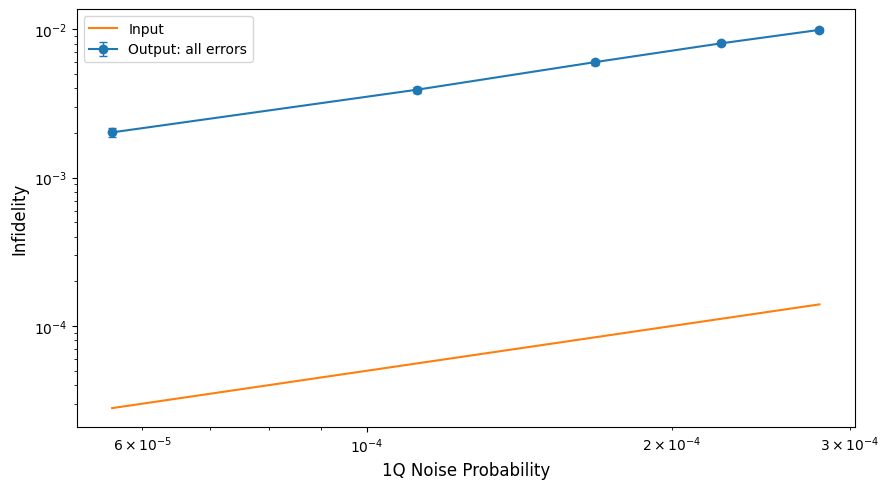

In [41]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    all_infidelity,
    yerr=all_fidelity_unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1,
    label='Output: all errors'
)
plt.plot(one_qubit_gate_error_prob, all_input_infidelity, label='Input')
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

# What is the success probability

In [ ]:
shots = 100_000
success_prob_list = []

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()

    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])

    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas00 = len(res_statevectors['0x0'])
    num_success = 0
    for shot in res_statevectors['0x0']:
        fid = state_fidelity(shot, ideal)
        if (round(fid, 2) == 1.00):
            num_success += 1 
            
    success_prob_list.append(num_success / num_meas00)

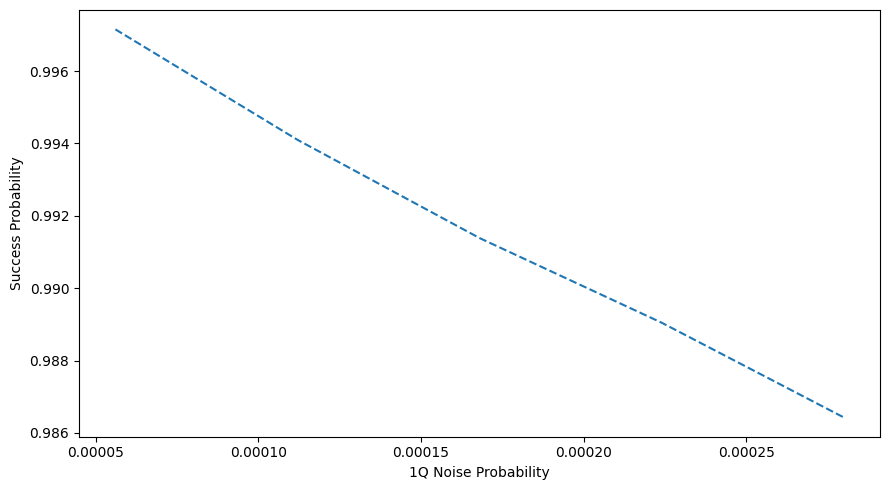

In [45]:
plt.figure(figsize=(9,5))
plt.plot(one_qubit_gate_error_prob, success_prob_list, linestyle='--')
plt.xlabel('1Q Noise Probability')
plt.ylabel('Success Probability')
plt.tight_layout()
plt.show()

# Circuit Component Analysis

In [40]:
# Entire distillation circuit is ideal
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_dm['0x0'][0]))
    
plot1_y = [1 - f for f in fidelity_results]

In [41]:
# Only idling errors
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_dm['0x0'][0]))
    
plot2_y = [1 - f for f in fidelity_results]

In [42]:
# Only measurement errors
fidelity_results = []
plot3_y_unc = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    fidelity_results.append(sumfid)
    plot3_y_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )
    
plot3_y = [1 - f for f in fidelity_results]

In [43]:
# Only cz errors
fidelity_results = []
plot4_y_unc = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_dm['0x0'][0]))
    
plot4_y = [1 - f for f in fidelity_results]

In [44]:
# Only hadamard errors
fidelity_results = []
plot5_y_unc = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_dm['0x0'][0]))
    
plot5_y = [1 - f for f in fidelity_results]

In [63]:
# --- APS-style global settings ---
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

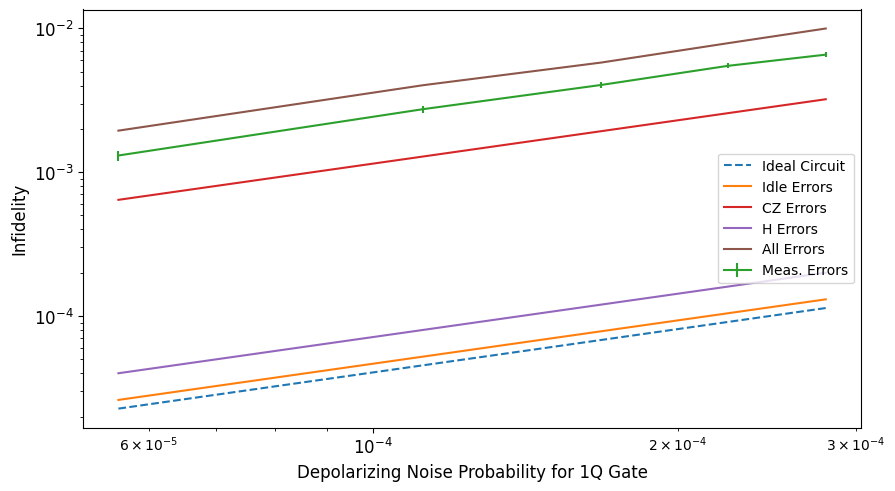

In [27]:
# Every plot without input and ideal circuit
plt.figure(figsize=(9,5))

plt.plot(one_qubit_gate_error_prob, plot1_y, linestyle=f'--', label='Ideal Circuit')
plt.plot(one_qubit_gate_error_prob, plot2_y, label='Idle Errors')
plt.errorbar(one_qubit_gate_error_prob, plot3_y, yerr=plot3_y_unc, label='Meas. Errors')
plt.plot(one_qubit_gate_error_prob, plot4_y, label='CZ Errors')
plt.plot(one_qubit_gate_error_prob, plot5_y, label='H Errors')
plt.plot(one_qubit_gate_error_prob, all_infidelity, label='All Errors')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Depolarizing Noise Probability for 1Q Gate', fontsize=12)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

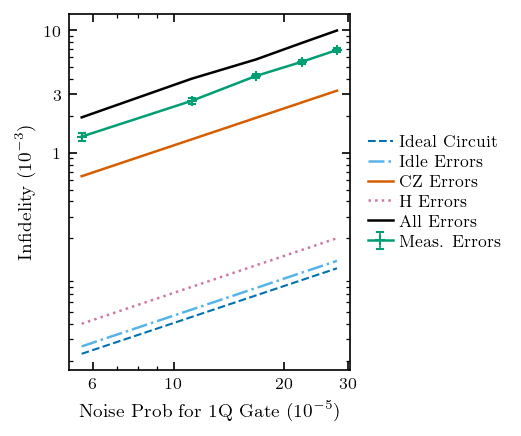

In [64]:
yscale = 1e-3
xscale = 1e-5

# Use double-column width since 6 lines + legend need the room
fig, ax = plt.subplots(figsize=(3.375, 2.8))

# Wong colorblind-safe palette + distinct linestyles
ax.plot(one_qubit_gate_error_prob, plot1_y,
        color='#0072B2', linestyle='--',  linewidth=1.0, label='Ideal Circuit')
ax.plot(one_qubit_gate_error_prob, plot2_y,
        color='#56B4E9', linestyle='-.',  label='Idle Errors')
ax.plot(one_qubit_gate_error_prob, plot4_y,
        color='#D55E00', linestyle='-',   label='CZ Errors')
ax.plot(one_qubit_gate_error_prob, plot5_y,
        color='#CC79A7', linestyle=':',   label='H Errors')
ax.plot(one_qubit_gate_error_prob, all_infidelity,
        color='#000000', linestyle='-',   label='All Errors')
ax.errorbar(one_qubit_gate_error_prob, plot3_y, yerr=plot3_y_unc,
            fmt='+-', color='#009E73', capsize=2,
            markersize=5, elinewidth=0.8, label='Meas. Errors')

ax.set_xscale('log')
ax.set_yscale('log')

# Explicit, clean tick locations
ax.set_xticks([6e-5, 1e-4, 2e-4, 3e-4])
ax.set_yticks([1e-3, 3e-3, 1e-2])

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/xscale:g}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/yscale:g}'))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

# Inward ticks on all four sides
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    handlelength=1.5,   # shorter line samples
    handletextpad=0.4,  # less space between line and label
    labelspacing=0.3,   # less vertical space between entries
)

ax.set_ylabel(r'Infidelity ($10^{-3}$)')
ax.set_xlabel(r'Noise Prob for 1Q Gate ($10^{-5}$)')

fig.tight_layout(pad=0.4)

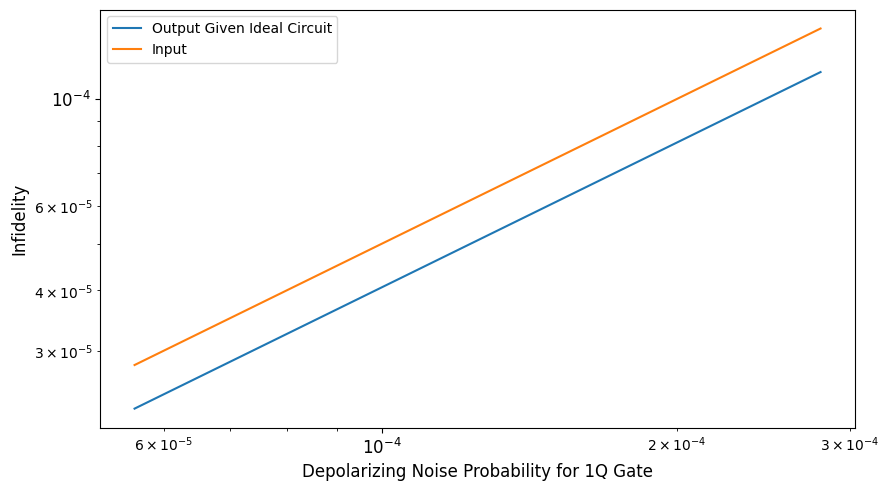

In [31]:
# Plotting both together
plt.figure(figsize=(9,5))

plt.plot(one_qubit_gate_error_prob, plot1_y, label='Output Given Ideal Circuit')
plt.plot(one_qubit_gate_error_prob, all_input_infidelity, label='Input')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Depolarizing Noise Probability for 1Q Gate', fontsize=12)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

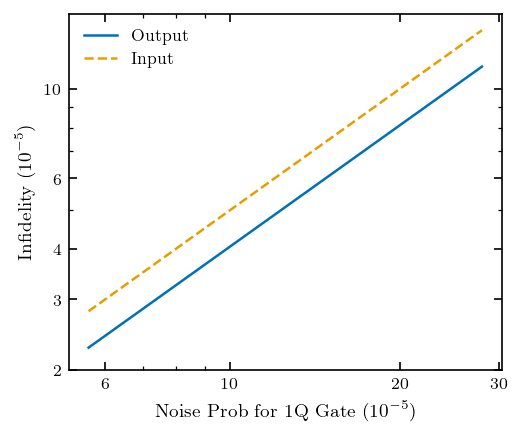

In [65]:
scale = 1e-5

# Single-column APS width
fig, ax = plt.subplots(figsize=(3.375, 2.8))

# Colorblind-safe, grayscale-friendly colors + distinct line styles
ax.plot(one_qubit_gate_error_prob, plot1_y,
        color='#0072B2', linestyle='-',  label='Output')
ax.plot(one_qubit_gate_error_prob, all_input_infidelity,
        color='#E69F00', linestyle='--', label='Input')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xticks([6e-5, 1e-4, 2e-4, 3e-4])
ax.set_yticks([2e-5, 3e-5, 4e-5, 6e-5, 1e-4])

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/scale:g}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/scale:g}'))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

# Inward ticks on all four sides
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.legend(frameon=False, loc='upper left')
ax.set_ylabel(r'Infidelity ($10^{-5}$)')
ax.set_xlabel(r'Noise Prob for 1Q Gate ($10^{-5}$)')

fig.tight_layout(pad=0.4)

Text(0.0, 1.0, '(b)')

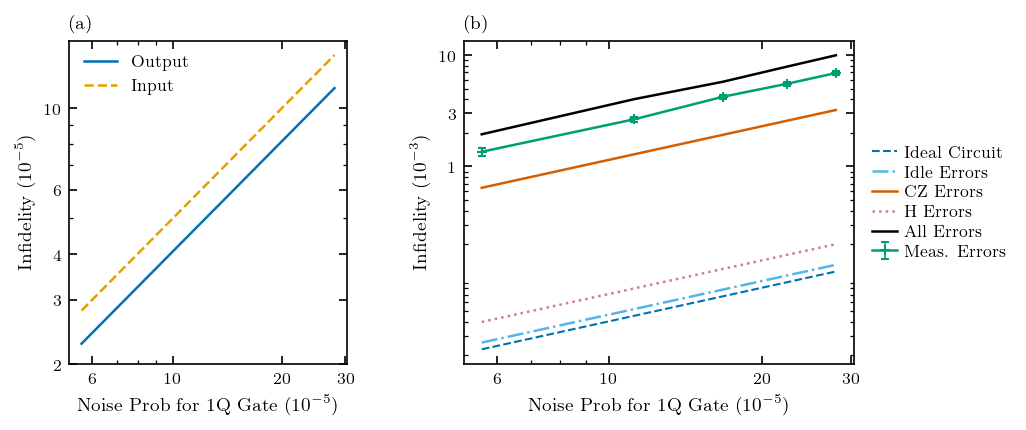

In [66]:
fig = plt.figure(figsize=(6.75, 2.8))

# Give plot 2 more width to accommodate the outside legend
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.4], wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Plot 1 ───────────────────────────────────────────────
scale = 1e-5
ax1.plot(one_qubit_gate_error_prob, plot1_y,
         color='#0072B2', linestyle='-', label='Output')
ax1.plot(one_qubit_gate_error_prob, all_input_infidelity,
         color='#E69F00', linestyle='--', label='Input')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xticks([6e-5, 1e-4, 2e-4, 3e-4])
ax1.set_yticks([2e-5, 3e-5, 4e-5, 6e-5, 1e-4])
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/scale:g}'))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/scale:g}'))
ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.yaxis.set_minor_formatter(NullFormatter())
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.tick_params(which='major', length=4)
ax1.tick_params(which='minor', length=2)
ax1.legend(frameon=False, loc='upper left')
ax1.set_ylabel(r'Infidelity ($10^{-5}$)')
ax1.set_xlabel(r'Noise Prob for 1Q Gate ($10^{-5}$)')
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
xscale, yscale = 1e-5, 1e-3
ax2.plot(one_qubit_gate_error_prob, plot1_y,
         color='#0072B2', linestyle='--', linewidth=1.0, label='Ideal Circuit')
ax2.plot(one_qubit_gate_error_prob, plot2_y,
         color='#56B4E9', linestyle='-.', label='Idle Errors')
ax2.plot(one_qubit_gate_error_prob, plot4_y,
         color='#D55E00', linestyle='-', label='CZ Errors')
ax2.plot(one_qubit_gate_error_prob, plot5_y,
         color='#CC79A7', linestyle=':', label='H Errors')
ax2.plot(one_qubit_gate_error_prob, all_infidelity,
         color='#000000', linestyle='-', label='All Errors')
ax2.errorbar(one_qubit_gate_error_prob, plot3_y, yerr=plot3_y_unc,
             fmt='+-', color='#009E73', capsize=2,
             markersize=5, elinewidth=0.8, label='Meas. Errors')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xticks([6e-5, 1e-4, 2e-4, 3e-4])
ax2.set_yticks([1e-3, 3e-3, 1e-2])
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/xscale:g}'))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/yscale:g}'))
ax2.xaxis.set_minor_formatter(NullFormatter())
ax2.yaxis.set_minor_formatter(NullFormatter())
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.tick_params(which='major', length=4)
ax2.tick_params(which='minor', length=2)
ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False,
           handlelength=1.5, handletextpad=0.4, labelspacing=0.3)
ax2.set_ylabel(r'Infidelity ($10^{-3}$)')
ax2.set_xlabel(r'Noise Prob for 1Q Gate ($10^{-5}$)')
ax2.set_title('(b)', loc='left', fontsize=9)

calcualting each components contribution to the total noise

In [50]:
sum_c_list = []
for i in range(len(one_qubit_gate_error_prob)):
    sum_c_list.append(plot3_y[i] + plot4_y[i] + plot5_y[i])

for i, e in enumerate(one_qubit_gate_error_prob):
    print(f"For 1Q error probability = {e}")
    print(f"Hadamard Fractions = {plot5_y[i] / sum_c_list[i]}")
    print(f"CZ Fractions = {plot4_y[i] / sum_c_list[i]}")
    print(f"Measurement Fractions = {plot3_y[i] / sum_c_list[i]}")
    print("")

For 1Q error probability = 5.6e-05
Hadamard Fractions = 0.019659721141348036
CZ Fractions = 0.31544887553062384
Measurement Fractions = 0.6648914033280281

For 1Q error probability = 0.000112
Hadamard Fractions = 0.019933833023123352
CZ Fractions = 0.3198733624226149
Measurement Fractions = 0.6601928045542618

For 1Q error probability = 0.000168
Hadamard Fractions = 0.01911041374551201
CZ Fractions = 0.30668525109025346
Measurement Fractions = 0.6742043351642345

For 1Q error probability = 0.000224
Hadamard Fractions = 0.019406878346421904
CZ Fractions = 0.3114683314997985
Measurement Fractions = 0.6691247901537796

For 1Q error probability = 0.00028
Hadamard Fractions = 0.019395155309155053
CZ Fractions = 0.31130546622499206
Measurement Fractions = 0.6692993784658529



# Saving and Loading Data

In [45]:
# Saving Data
np.savez("physical_level_component_analysis.npz",
    plot1_y=plot1_y,
    plot2_y=plot2_y,
    plot3_y=plot3_y,
    plot3_y_unc=plot3_y_unc,
    plot4_y=plot4_y,
    plot4_y_unc=plot4_y_unc,
    plot5_y=plot5_y,
    plot5_y_unc=plot5_y_unc,
    all_input_infidelity=all_input_infidelity,
    all_infidelity=all_infidelity,
)

In [ ]:
# Loading Data
data = np.load("physical_level_component_analysis.npz")
plot1_y = data["plot1_y"]
plot2_y = data["plot2_y"]
plot3_y = data["plot3_y"]
plot3_y_unc = data["plot3_y_unc"]
plot4_y = data["plot4_y"]
plot4_y_unc = data["plot4_y_unc"]
plot5_y = data["plot5_y"]
plot5_y_unc = data["plot5_y_unc"]
all_input_infidelity = data["all_input_infidelity"]
all_infidelity = data["all_infidelity"]